# The axisartist toolkit

`axisartist` uses a special artist (AxisArtist) that can handle ticks, ticklines, etc for **curved coordinate systems**.<br/>


## axisartist

To create an Axes:

<Axes: >

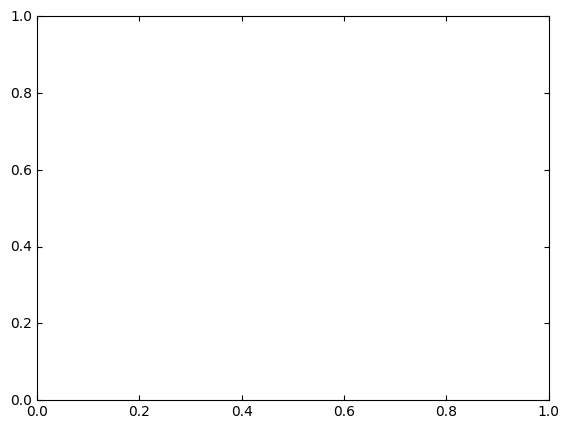

In [1]:
import matplotlib.pyplot as plt
import mpl_toolkits.axisartist as AA

fig = plt.figure()
# Dimensions of the new Axes as fractions of Figure width and height.
# (left, bottom, width, height)
fig.add_axes((0.1, 0.1, 0.8, 0.8), axes_class=AA.Axes)

To create a subplot:

<Axes: >

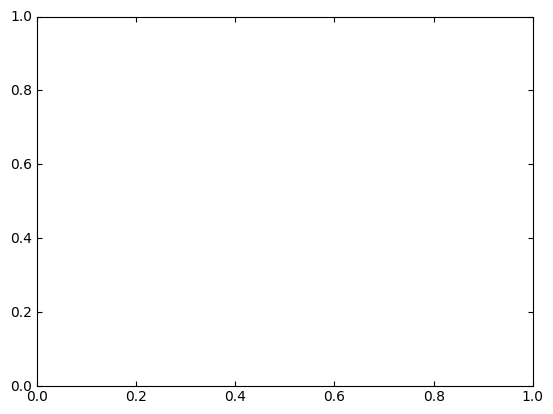

In [2]:
fig = plt.figure()

# The three digits refet to : nrows, ncols, index. 111 is the default anyway.
fig.add_subplot(111, axes_class=AA.Axes)

The four axis spines are accessed as ax["left"], ax["right"] etc.<br/>
So, to hide the right and top spines:

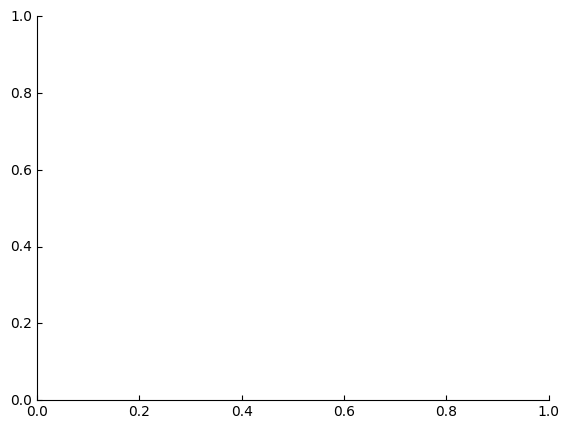

In [3]:
fig = plt.figure()
ax = fig.add_axes((0.1, 0.1, 0.8, 0.8), axes_class=AA.Axes)
ax.axis["right"].set_visible(False)  # type: ignore
ax.axis["top"].set_visible(False)  # type: ignore

# The mplot3d toolkit

## Line Plots

### Parametric Curve

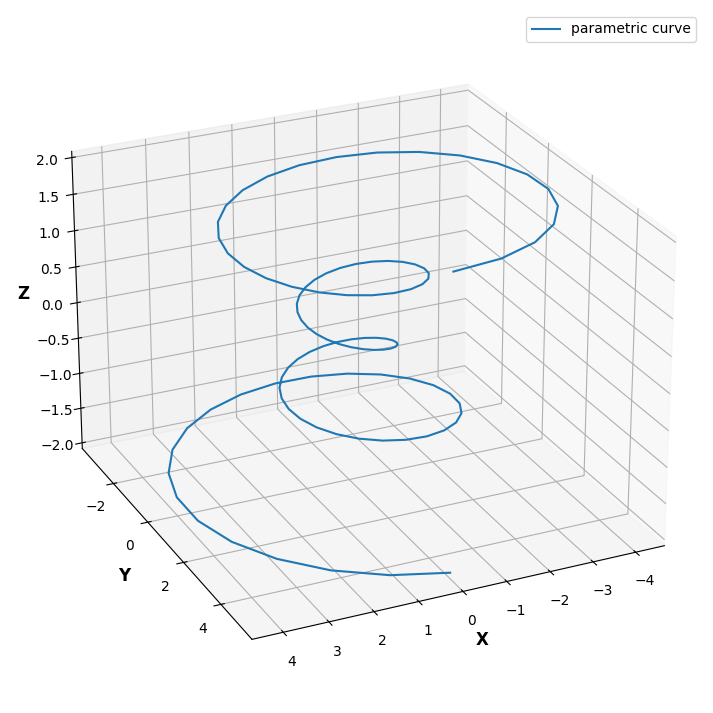

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create 3D axes with projection="3d"
ax = plt.figure(figsize=(11, 9)).add_subplot(projection="3d")

# Prepare arrays x, y, z
theta = np.linspace(-4 * np.pi, 4 * np.pi, 100)
z = np.linspace(-2, 2, 100) # vertical z-axis 
r = z**2 + 1    # radius
x = r * np.sin(theta)   # x-axis
y = r * np.cos(theta)   # y-axis

font_props = {"fontweight": "bold", "fontsize": 12}
ax.plot(x, y, z, label="parametric curve")
ax.set_xlabel("X", **font_props)
ax.set_ylabel("Y", **font_props)
ax.set_zlabel("Z", **font_props)
ax.view_init(elev=25, azim=65)  # elevate camera 25deg vertically/rotate camera 65deg horizontally
ax.legend()

plt.show()

### Scatter Plots

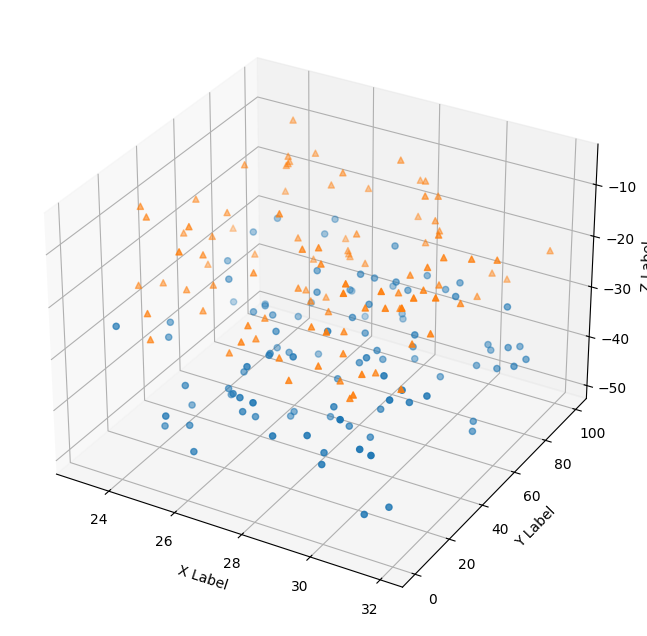

In [14]:
def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin) * np.random.rand(n) + vmin


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100] and z in [zlow, zhigh].
for m, zlow, zhigh in [("o", -50, -25), ("^", -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)

    ax.scatter(xs, ys, zs, marker=m)  # type: ignore

ax.set_xlabel("X Label")
ax.set_ylabel("Y Label")
ax.set_zlabel("Z Label")

plt.show()

### Bar Plots

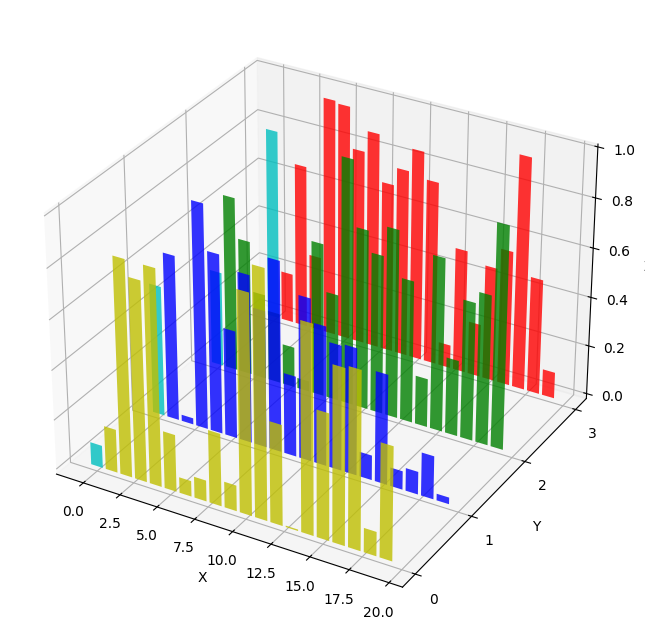

In [18]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

colors = ["r", "g", "b", "y"]
yticks = [3, 2, 1, 0]

for c, k in zip(colors, yticks):
    # Generate the random data for the y=k "layer"
    xs = np.arange(20)
    ys = np.random.rand(20)

    # You can provide either a single color or an array with the same length as
    # xs and ys. To demonstrate this, we color the first bar of each set cyan.
    cs = [c] * len(xs)
    cs[0] = "c"

    # Plot the bar graph given by xs and ys on the plane y=k with 80% opacity.
    ax.bar(xs, ys, zs=k, zdir="y", color=cs, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# On the y-axis let's only label the discrete values that we have data for
ax.set_yticks(yticks)

plt.show()